In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df3 = pd.read_pickle('../data/df3_with_regions.pkl')

In [3]:
df5 = pd.read_pickle('../data/df5.pkl')

final termination reasons by patron category (excluding transfers, journey termination and return/intermediate trips)

In [44]:
df4 = df3[(df3['BTS_flag'] == True) &
          (df3['BTS_flag_reason'] != 'last_stage') &
          (df3['BTS_flag_reason'] != 'return_or_intermediate') &
          (df3['BTS_flag_reason'] != 'null_time_gap')]

In [45]:
df_top10 = (
    df4.groupby('PATRON_CATG_DESC_TXT')['BTS_flag_reason']
       .value_counts()
       .rename('count')
       .reset_index()
       .sort_values(['BTS_flag_reason', 'count'], ascending=[True, False])
       .groupby('PATRON_CATG_DESC_TXT')
       .head(10)
)

In [ ]:
top_reasons = (
    df4['BTS_flag_reason']
    .value_counts()
    .head(10)
    .index
)

df_plot = (
    df3[df3['BTS_flag_reason'].isin(top_reasons)]
    .groupby(['BTS_flag_reason', 'PATRON_CATG_DESC_TXT'])
    .size()
    .reset_index(name='count')
)

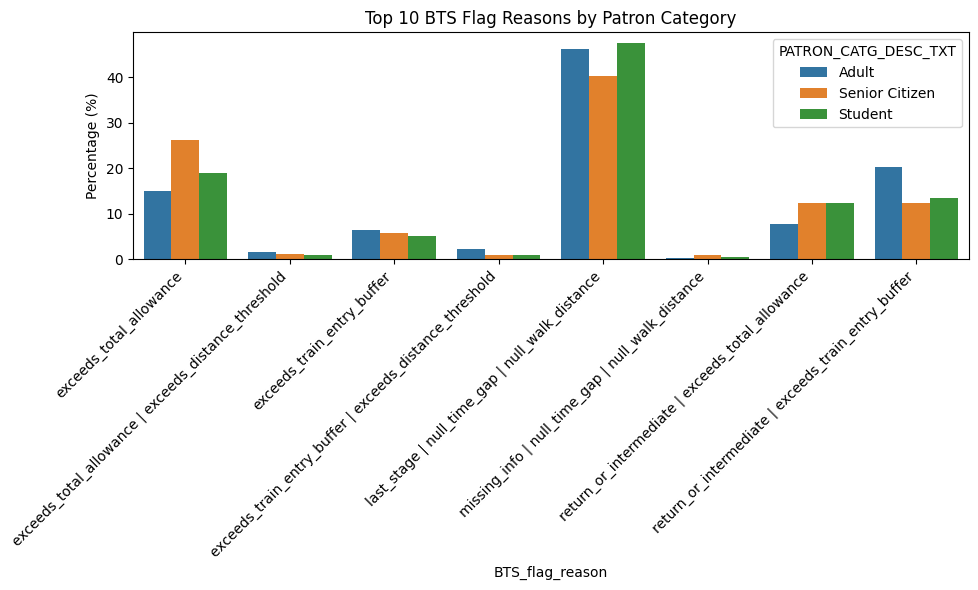

In [46]:
top_reasons_pct = (
    df4['BTS_flag_reason']
    .value_counts(normalize=True)
    .head(10)
    .index
)

df_plot2 = (
    df4[df4['BTS_flag_reason'].isin(top_reasons_pct)]
    .groupby(['PATRON_CATG_DESC_TXT', 'BTS_flag_reason'])
    .size()
    .reset_index(name='count')
)

# percentage within each category
df_plot2['percentage'] = df_plot2.groupby('PATRON_CATG_DESC_TXT')['count'] \
                                 .transform(lambda x: x / x.sum() * 100)

plt.figure(figsize=(10,6))
sns.barplot(
    data=df_plot2,
    x='BTS_flag_reason',
    y='percentage',
    hue='PATRON_CATG_DESC_TXT'
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Percentage (%)')
plt.title('Top 10 BTS Flag Reasons by Patron Category')
plt.tight_layout()
plt.show()

In [ ]:
df_plot3 = (
    df4[df4['BTS_flag_reason'].isin(top_reasons)]
    .groupby(['BTS_flag_reason', 'PATRON_CATG_DESC_TXT'])
    .size()
    / len(df4)
).reset_index(name='overall percentage')

In [47]:
df_top10_each = (
    df4.groupby('PATRON_CATG_DESC_TXT')['BTS_flag_reason']
       .value_counts()
       .rename('count')
       .reset_index()
       .groupby('PATRON_CATG_DESC_TXT')
       .head(10)
)

df_top10_each['percentage'] = (
    df_top10_each.groupby('PATRON_CATG_DESC_TXT')['count']
    .transform(lambda x: x / x.sum() * 100)
)

categories = df_top10_each['PATRON_CATG_DESC_TXT'].unique()

In [ ]:
fig, axes = plt.subplots(1, len(categories), figsize=(18,6), sharey=True)

for i, cat in enumerate(categories):
    df_cat = df_top10_each[df_top10_each['PATRON_CATG_DESC_TXT'] == cat]

    sns.barplot(
        data=df_cat,
        x='count',
        y='BTS_flag_reason',
        order=df_cat.sort_values('count', ascending=False)['BTS_flag_reason'],
        ax=axes[i]
    )

    axes[i].set_title(cat)
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('Reason' if i == 0 else '')

plt.suptitle('Top 10 BTS Flag Reasons per Patron Category')
plt.tight_layout()
plt.show()

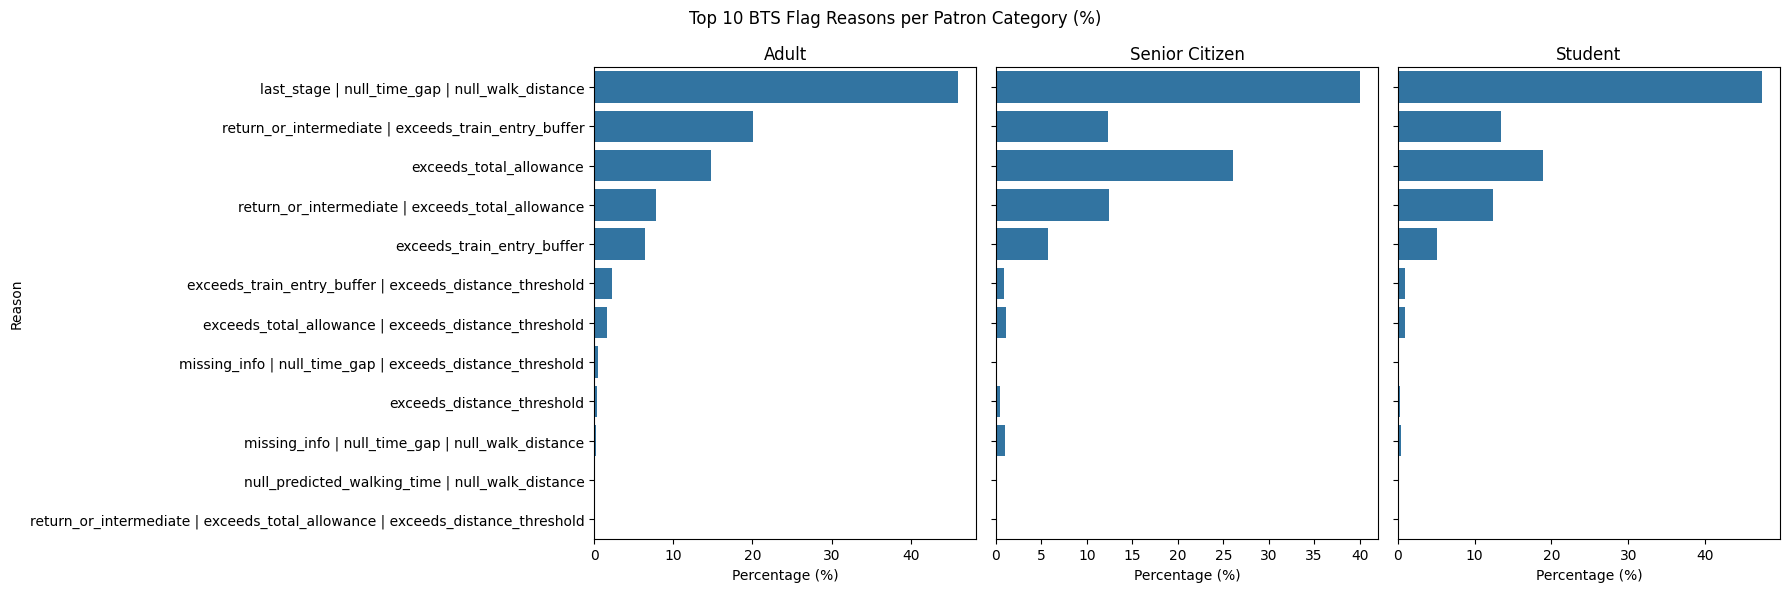

In [48]:
fig, axes = plt.subplots(1, len(categories), figsize=(18,6), sharey=True)

for i, cat in enumerate(categories):
    df_cat = df_top10_each[df_top10_each['PATRON_CATG_DESC_TXT'] == cat]

    sns.barplot(
        data=df_cat,
        x='percentage',
        y='BTS_flag_reason',
        order=df_cat.sort_values('percentage', ascending=False)['BTS_flag_reason'],
        ax=axes[i]
    )

    axes[i].set_title(cat)
    axes[i].set_xlabel('Percentage (%)')
    axes[i].set_ylabel('Reason' if i == 0 else '')

plt.suptitle('Top 10 BTS Flag Reasons per Patron Category (%)')
plt.tight_layout()
plt.show()

final termination reasons by patron category (percentage, excluding transfers)

In [ ]:
# percentage by patron category
df4.groupby('PATRON_CATG_DESC_TXT')['BTS_flag_reason'] \
    .value_counts(normalise=True) \
    .reset_index(name='pct_within_group')

In [ ]:
# overall percentage
df4['BTS_flag_reason'] \
    .value_counts(normalize=True) \
    .reset_index(name='pct_overall') \
    .rename(columns={'index': 'BTS_flag_reason'})

overall transfer metrics by patron category

In [ ]:
def get_df_val(data, correct_data):
    df = data[['CRD_NUM', 'JRNY_ID_NUM', 'ENTRY_TM', 'EXIT_TM', 'TRNSPT_MODE_CD', 'journey_termination_flag', 
    'ORIG_STATION_NAME', 'dest_region']]
    correct_df = correct_data[['CRD_NUM', 'JRNY_ID_NUM', 'JRNY_START_TM', 'JRNY_END_TM', 'PATRON_CATG_ID_NUM']]

    correct_df['service_day'] = (correct_df['JRNY_START_TM'] - pd.Timedelta(hours=5)).dt.date
    target_day = pd.Timestamp('2025-02-12').date()
    correct_df = correct_df[correct_df['service_day'] == target_day].reset_index(drop=True)
    correct_df = correct_df[correct_df['PATRON_CATG_ID_NUM'].isin([1, 3, 4])].reset_index(drop=True)

    df_val = df.merge(
        correct_df[['CRD_NUM', 'JRNY_ID_NUM', 'JRNY_START_TM', 'JRNY_END_TM']],
        on=['CRD_NUM', 'JRNY_ID_NUM'],
        how='inner'
    )

    df_val = df_val[
        (df_val['ENTRY_TM'] >= df_val['JRNY_START_TM']) &
        (df_val['EXIT_TM'] <= df_val['JRNY_END_TM'])
    ].reset_index(drop=True)

    df_val = df_val.sort_values(['CRD_NUM', 'ENTRY_TM']).reset_index(drop=True)
    df_val['next_JRNY_ID_NUM'] = df_val.groupby('CRD_NUM')['JRNY_ID_NUM'].shift(-1)
    df_val['true_transfer'] = (df_val['JRNY_ID_NUM'] == df_val['next_JRNY_ID_NUM'])
    df_val = df_val[df_val['next_JRNY_ID_NUM'].notna()].reset_index(drop=True)

    return df_val    

In [ ]:
def get_metrics(df):
    actual_transfer = df['true_transfer']
    pred_transfer = ~df['journey_termination_flag_spatial']

    tp = (actual_transfer & pred_transfer).sum()     # actual transfer, predicted transfer
    tn = (~actual_transfer & ~pred_transfer).sum()   # actual new journey, predicted new journey
    fp = (~actual_transfer & pred_transfer).sum()    # actual new journey, predicted transfer (merge error)
    fn = (actual_transfer & ~pred_transfer).sum()    # actual transfer, predicted new journey (split error)

    total_actual_transfers = actual_transfer.sum()

    print(f"TP: {tp:,}  TN: {tn:,}  FP: {fp:,}  FN: {fn:,}")
    print(f"Split rate  (FN / actual transfers): {fn / total_actual_transfers:.4f}")
    print(f"Merge rate  (FP / actual transfers): {fp / total_actual_transfers:.4f}")
    print(f"Sensitivity (TP / (TP+FN)):          {tp / (tp + fn):.4f}")
    print(f"Specificity (TN / (TN+FP)):          {tn / (tn + fp):.4f}")
    print(f"Accuracy    ((TP+TN) / total):       {(tp + tn) / len(df):.4f}")

    print(pd.crosstab(
        actual_transfer,
        pred_transfer,
        rownames=['Actual transfer'],
        colnames=['Predicted transfer']
    ))

In [ ]:
df_val = get_df_val(df3, df5)
get_metrics(df_val)

In [ ]:
for group_name, group_df in df_val.groupby('PATRON_CATG_DESC_TXT'):
    print(f"\nGroup: {group_name}")
    get_metrics(group_df)

getting wrongly split and wrongly merged rides from our classifier

In [ ]:
def get_misclassified(df_val):
    actual_transfer = df_val['true_transfer']
    pred_transfer = ~df_val['journey_termination_flag_spatial']    

    fp_rows = (~actual_transfer & pred_transfer)
    fn_rows = (actual_transfer & ~pred_transfer)

    fp_df = df_val[fp_rows]
    fn_df = df_val[fn_rows]

    return fp_df, fn_df

In [ ]:
fp, fn = get_misclassified(df3, df5)

final termination reasons by patron category [wrongly merged only]

In [ ]:
fp.groupby('PATRON_CATG_DESC_TXT')['BTS_flag_reason'].value_counts().reset_index(name='count')

final termination reasons by patron category (percentage) [wrongly merged only]

In [ ]:
# percentage by patron category
fp.groupby('PATRON_CATG_DESC_TXT')['BTS_flag_reason'] \
    .value_counts(normalise=True) \
    .reset_index(name='pct_within_group')

In [ ]:
# overall percentage
fp['BTS_flag_reason'] \
    .value_counts(normalize=True) \
    .reset_index(name='pct_overall') \
    .rename(columns={'index': 'BTS_flag_reason'})